Dean Hickman

CS 251/2: Data Analysis and Visualization

Fall 2024

Project 5: Clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from kmeans import KMeans

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)


# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 2: Image Segmentation and compression

In this task, you will apply K-means to one image and to compress it (*image compression*). The idea is that you will find $k$ RGB color centroids in the image, then replace each pixel in the image with the nearest centroid. This will compress an image, by only using $k$ colors to represent it. You can also think of this as doing a simple image region segmentation: regions with similar colors will belong to the same cluster. It also makes some cool retro effects!

### 2a. Load in baby bird image

- Use the imported `imread` method below to load in the `baby_bird.jpg` image.
- Use `plt.imshow` to display it in the notebook below. Turn off plot ticks!

In [2]:
from matplotlib.image import imread

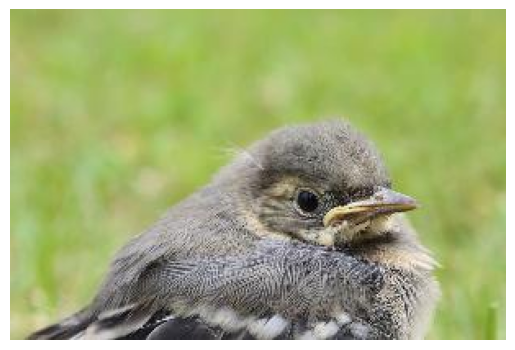

In [3]:
picture = imread('data/baby_bird.jpg')
plt.imshow(picture)
plt.axis('off')
plt.show()

### 2b. Preprocess image

- Fill in the function below to collapse (flatten) the 2D image into a big 1D vector of RGB values. For example, for the bird image, your function should take the shape `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`.
- Reshape the bird image from `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`. Final shape for baby bird image should be: `(61206, 3)`

In [4]:
def flatten(img):
    '''Flattens `img` to N 1D vectors.
    For example, for an RGB image, `(num_rows, num_cols, rgb)` -> `(num_rows*num_cols, rgb)`.
    
    Parameters:
    -----------
    img: ndarray. shape=(num_rows, num_cols, rgb)
    
    Returns:
    -----------
    Flattened `img`. ndarray. shape=(num_rows*num_cols, rgb)
    '''
    num_rows = img.shape[0]
    num_cols = img.shape[1]
    rgb = img.shape[2]
    new_image = img.reshape(num_rows*num_cols, rgb)
    
    return new_image

In [5]:
flattened = flatten(picture)
print(f'Image, shape: {flattened.shape}')

Image, shape: (61206, 3)


### 2c. Cluster RGB values in image

- Run K-means on the bird data vector.
- Implement `replace_color_with_centroid`: replace every pixel in the image with the nearest centroid RGB value.
- Compress the image by running `replace_color_with_centroid`.

In [6]:
bird_k = KMeans(flattened)
bird_k.cluster(16)
bird_k.replace_color_with_centroid()
print(bird_k.get_data())

[[0.59599 0.69599 0.31868]
 [0.59599 0.69599 0.31868]
 [0.59599 0.69599 0.31868]
 ...
 [0.70881 0.75295 0.53416]
 [0.70881 0.75295 0.53416]
 [0.70881 0.75295 0.53416]]


### 2d. Postprocessing and visualization

- Rehape the compressed image data back to its original dimensions and cast the ndarray so that it stores ints.
- Plot it below.

(202, 303, 3)


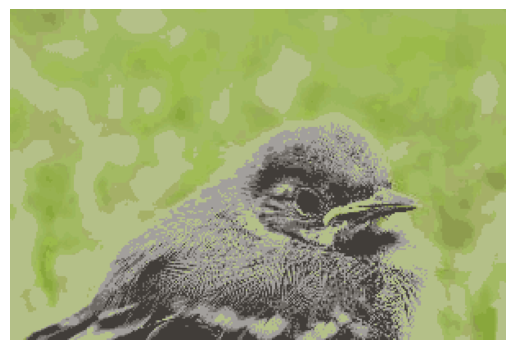

In [7]:
num_rows = picture.shape[0]
num_cols = picture.shape[1]
rgb = picture.shape[2]
reshape_bird = bird_k.get_data().reshape(num_rows, num_cols, rgb)
print(reshape_bird.shape)

plt.imshow(reshape_bird)
plt.xticks([])
plt.yticks([])
plt.show()

### 2e. Run K-means and compress an image of your choice

Smaller images run a lot faster.

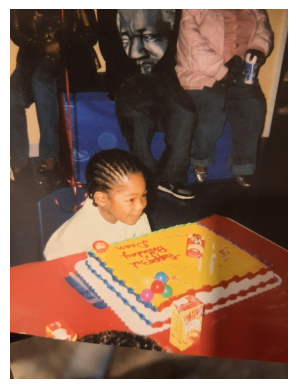

In [8]:
me = plt.imread('data/part0.jpg')
plt.imshow(me)
plt.xticks([])
plt.yticks([])
plt.show()

In [13]:
flattened = flatten(me)
dean_k = KMeans(flattened)
dean_k.cluster(16)

(443.62143593413725, 2)

In [14]:
dean_k.replace_color_with_centroid()

In [15]:
num_rows = me.shape[0]
num_cols = me.shape[1]
rgb = me.shape[2]
reshape_me= dean_k.get_data().reshape(num_rows, num_cols, rgb)

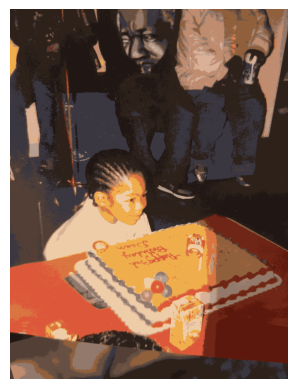

In [16]:
plt.imshow(reshape_me)
plt.xticks([])
plt.yticks([])
plt.show()